# Negative-pH Calibration  (down to pH -5)

In the strong-acid / acid-error region the glass electrode is **non-Nernstian**.
The response is modeled with a **logistic** function:

$$\text{EMF}(\text{pH}) = \dfrac{A}{1 + \exp\!\big(k\,(\text{pH}-x_0)\big)}$$

**Calibration standards.** Negative-pH calibration combines two standard types:

1. **NIST/DIN buffers** at pH **1.68, 3, 4** (anchors the higher-pH end).
2. **H₂SO₄ standards** covering pH **1 down to -5**. Use **at least 5 H₂SO₄ points**
   for a reliable fit; more points across the range give a better logistic.

Both groups are entered separately and combined for the fit.

Choose one of two options:

- **Option 1 - negative pH at a SPECIFIC temperature.** Fit one logistic curve, then
  predict sample pH (down to pH -5) at that temperature.
- **Option 2 - negative pH at ANY temperature (5-50 °C).** Fit a logistic to every
  replicate run, then make $A$, $k$, $x_0$ temperature-dependent using a polynomial
  whose degree is chosen automatically by **AICc**. Predict pH at any temperature
  in range.

Inverting the logistic to get pH from EMF:

$$\text{pH} = x_0 + \dfrac{1}{k}\,\ln\!\left(\dfrac{A}{\text{EMF}} - 1\right)$$

All input is via **inline arrays**.

*From Saleesongsom et al., ACS Omega (2026).*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import curve_fit
from scipy import stats

np.set_printoptions(suppress=True)

def logistic(pH, A, k, x0):
    return A / (1.0 + np.exp(k * (pH - x0)))

def invert_logistic(emf, A, k, x0):
    ratio = A / emf - 1.0
    return x0 + np.log(ratio) / k if ratio > 0 else np.nan


---
## Option 1 - negative pH at a specific temperature

### Step 1. Build the calibration
Enter the two standard groups measured at one temperature. **NIST/DIN buffers** are
only prepared at **pH 1.68, 3 and 4** - these anchor the higher-pH plateau. The
**H₂SO₄ series** then reaches the strong-acid region; H₂SO₄ standards can be made
across a wide pH range, but here they cover roughly **pH 1 down to -5** (use
**>= 5 points**) where the buffers cannot reach. The two groups are combined for a
single logistic fit.

Logistic fit @ 38.5 C:  A = 537.03  k = 0.4890  x0 = 2.701   R^2 = 0.9993


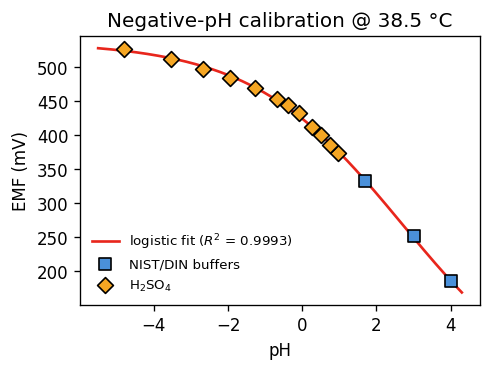

In [2]:
# ============ EDIT YOUR DATA (single temperature) ============
# Example below is a real ~38.5 C primatrode dataset.

# --- NIST/DIN buffer standards: ONLY pH 1.68, 3 and 4 ---
buffer_pH  = [1.68, 3.00, 4.00]       # certified NIST/DIN buffer pH
buffer_EMF = [331.9, 251.6, 185.5]    # measured EMF (mV)

# --- H₂SO₄ standards: here pH ~1 down to -5 (>= 5 points recommended) ---
# H₂SO₄ can also be prepared at higher pH, but only the low-pH points below the
# buffers' reach are needed to define the negative-pH response.
h2so4_pH   = [0.97, 0.76, 0.50, 0.27, -0.09, -0.39, -0.69, -1.27, -1.94, -2.67, -3.55, -4.80]
h2so4_EMF  = [373.4, 384.9, 399.6, 411.5, 432.0, 444.4, 453.2, 469.4, 484.3, 497.6, 511.8, 526.1]

T_C = 38.5
# =============================================================

buffer_pH,  buffer_EMF = np.asarray(buffer_pH, float),  np.asarray(buffer_EMF, float)
h2so4_pH,   h2so4_EMF  = np.asarray(h2so4_pH, float),   np.asarray(h2so4_EMF, float)
if len(h2so4_pH) < 5:
    print(f"WARNING: only {len(h2so4_pH)} H₂SO₄ point(s) - at least 5 are recommended.")

# combine the two standard groups
pH_data  = np.concatenate([buffer_pH, h2so4_pH])
EMF_data = np.concatenate([buffer_EMF, h2so4_EMF])
order = np.argsort(pH_data)
pH_data, EMF_data = pH_data[order], EMF_data[order]

p0 = [EMF_data.max() * 1.03, 0.5, np.median(pH_data)]
popt, _ = curve_fit(logistic, pH_data, EMF_data, p0=p0, maxfev=20000)
A1, k1, x01 = popt
resid = EMF_data - logistic(pH_data, *popt)
r2_1 = 1 - np.sum(resid**2) / np.sum((EMF_data - EMF_data.mean())**2)
print(f"Logistic fit @ {T_C} C:  A = {A1:.2f}  k = {k1:.4f}  x0 = {x01:.3f}   R^2 = {r2_1:.4f}")

fig, ax = plt.subplots(figsize=(4.2, 3.2), dpi=120)
xf = np.linspace(-5.5, pH_data.max() + 0.3, 400)
ax.plot(xf, logistic(xf, *popt), "-", color="#E8261C", lw=1.6, label=f"logistic fit ($R^2$ = {r2_1:.4f})")
ax.scatter(buffer_pH, buffer_EMF, s=45, marker="s", c="#4A90D9", edgecolors="black", zorder=3, label="NIST/DIN buffers")
ax.scatter(h2so4_pH,  h2so4_EMF,  s=45, marker="D", c="#F5A623", edgecolors="black", zorder=3, label="H$_2$SO$_4$")
ax.set_xlabel("pH"); ax.set_ylabel("EMF (mV)")
ax.legend(fontsize=8, frameon=False); ax.set_title(f"Negative-pH calibration @ {T_C} °C")
plt.tight_layout(); plt.show()


### Step 2. Predict sample pH
Enter sample EMF measured at the same temperature (works into negative pH).


In [3]:
# ============ EDIT YOUR SAMPLE EMF (same temperature) ============
sample_EMF = [400.0, 460.0, 510.0]     # measured EMF (mV)
# ================================================================

sample_EMF = np.atleast_1d(np.asarray(sample_EMF, float))
print(f"Predicted pH @ {T_C} C:")
for e in sample_EMF:
    ph = invert_logistic(e, A1, k1, x01)
    flag = "" if np.isfinite(ph) else "  (EMF at/above A plateau - out of range)"
    print(f"  EMF {e:8.2f} mV  ->  pH {ph:7.3f}{flag}")


Predicted pH @ 38.5 C:
  EMF   400.00 mV  ->  pH   0.511
  EMF   460.00 mV  ->  pH  -0.953
  EMF   510.00 mV  ->  pH  -3.306


---
## Option 2 - negative pH at any temperature (5-50 °C)

### Step 1. Load calibration data from Excel
The multi-temperature data live in **`calibration_datasets.xlsx`** (sheet
**`Negative`**). Each row is one measurement:

```
Temp_set_C | Replicate | pH | EMF_mV | Standard | Temp_measured_C
```

A **run** = one `(Temp_set_C, Replicate)` group and spans both standard types:
NIST/DIN buffers (`Standard = buffer`) and the H₂SO₄ series (`Standard = H2SO4`)
that reaches negative pH. The plot shows the raw EMF response coloured by
temperature (no fit yet).

**Ranges.** Parameters are modelled over **5-50 °C** (the 60 °C run is excluded)
and the calibration standards reach down to **pH -5** (`PH_MIN`). Adjust
`TEMP_MAX` / `PH_MIN` to change either limit.

In [4]:
# ===== LOAD NEGATIVE-pH DATA FROM EXCEL (edit the .xlsx, not this cell) =====
neg_df = pd.read_excel("calibration_datasets.xlsx", sheet_name="Negative")

TEMP_MAX = 50.0     # model logistic parameters up to this temperature (paper: 50 C)
PH_MIN   = -5.0     # calibration standards reach down to this pH (paper: -5)
neg_df = neg_df[(neg_df["Temp_measured_C"] <= TEMP_MAX) &
                (neg_df["pH"] >= PH_MIN)].copy()

runs = list(neg_df.groupby(["Temp_set_C", "Replicate"]))
n_T  = neg_df["Temp_set_C"].nunique()
print(f"{len(runs)} calibration runs across {n_T} temperatures "
      f"(pH >= {neg_df['pH'].min():.2f}, T <= {TEMP_MAX:.0f} C)")
assert n_T >= 3, "Provide data for at least 3 temperatures."

# shared arrays + temperature colour scale (autumn_r)
pH_all  = neg_df["pH"].to_numpy(float)
emf_all = neg_df["EMF_mV"].to_numpy(float)
T_all   = neg_df["Temp_measured_C"].to_numpy(float)
CMAP    = plt.cm.autumn_r
tnorm   = mpl.colors.Normalize(T_all.min(), T_all.max())
XLABEL  = r"pH = $-\log(a_{H^+})$"
# ==========================================================================


15 calibration runs across 5 temperatures (pH >= -4.80, T <= 50 C)


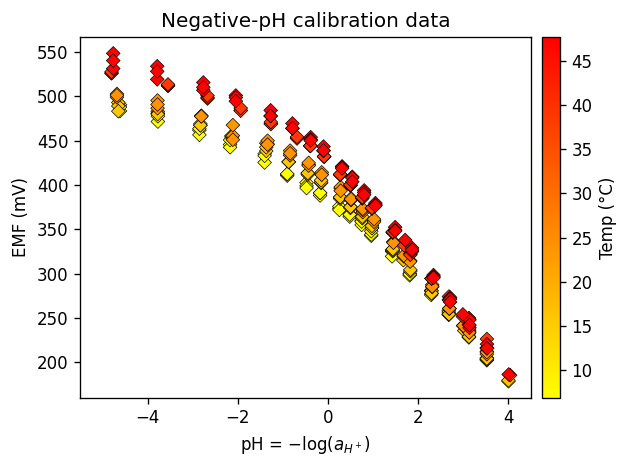

In [5]:
# ---- Plot the raw calibration data, coloured by temperature (no fit) ----
fig, ax = plt.subplots(figsize=(5.4, 4.0), dpi=120)
sc = ax.scatter(pH_all, emf_all, c=T_all, cmap=CMAP, norm=tnorm,
                marker="D", s=34, edgecolors="k", linewidths=0.4, zorder=3)
fig.colorbar(sc, ax=ax, pad=0.02).set_label("Temp (°C)")
ax.set_xlim(-5.5, 4.5)
ax.set_xlabel(XLABEL); ax.set_ylabel("EMF (mV)")
ax.set_title("Negative-pH calibration data")
plt.tight_layout(); plt.show()


### Step 2. Fit a logistic to every replicate run
The logistic is fit to **each replicate run separately** (not to replicate-averaged
points), capturing each replicate run's calibration curve. Each fit gives one
$(T, A, k, x_0)$ estimate; the scatter of these estimates is what the AICc degree
selection responds to. The plot repeats Step 1 and overlays every fitted logistic
curve, coloured by temperature.

In [6]:
recs, run_fits = [], []
for (Tset, rep), g in runs:
    g   = g.sort_values("pH")
    pH  = g["pH"].to_numpy(float)
    emf = g["EMF_mV"].to_numpy(float)
    T   = float(g["Temp_measured_C"].mean())
    n_h = int((g["Standard"] == "H2SO4").sum())
    if n_h < 5:
        print(f"  WARNING T~{Tset:.0f}C rep{rep}: only {n_h} H₂SO₄ point(s) (>=5 recommended)")
    popt, _ = curve_fit(logistic, pH, emf,
                        p0=[emf.max()*1.03, 0.5, np.median(pH)], maxfev=20000)
    A, k, x0 = popt
    r2 = 1 - np.sum((emf - logistic(pH, *popt))**2) / np.sum((emf - emf.mean())**2)
    recs.append((T, A, k, x0, r2)); run_fits.append((T, popt))

fit_df = pd.DataFrame(recs, columns=["T", "A", "k", "x0", "R2"]).sort_values("T")
Tp   = fit_df["T"].to_numpy()
parA = fit_df["A"].to_numpy(); park = fit_df["k"].to_numpy(); parx = fit_df["x0"].to_numpy()
print(fit_df.to_string(index=False,
      formatters={"T": "{:6.1f}".format, "A": "{:8.2f}".format,
                  "k": "{:7.4f}".format, "x0": "{:6.3f}".format, "R2": "{:6.4f}".format}))
print(f"\n{len(fit_df)} replicate fits feed the temperature model.")


     T        A       k     x0     R2
   6.9   507.05  0.4290  2.688 0.9979
   7.0   507.04  0.4248  2.718 0.9982
   7.2   496.49  0.4439  2.758 0.9990
  15.9   496.67  0.4965  2.786 0.9998
  15.9   502.06  0.4817  2.752 0.9995
  16.0   504.74  0.4695  2.723 0.9996
  23.8   506.70  0.4881  2.826 0.9989
  23.9   515.15  0.4797  2.752 0.9996
  24.0   508.29  0.4856  2.812 0.9980
  38.5   538.90  0.4788  2.711 0.9992
  38.6   541.91  0.4647  2.725 0.9988
  38.6   540.34  0.4859  2.672 0.9996
  47.3   540.27  0.5152  2.704 0.9996
  47.5   550.78  0.4883  2.625 0.9994
  47.7   559.10  0.4815  2.615 0.9996

15 replicate fits feed the temperature model.


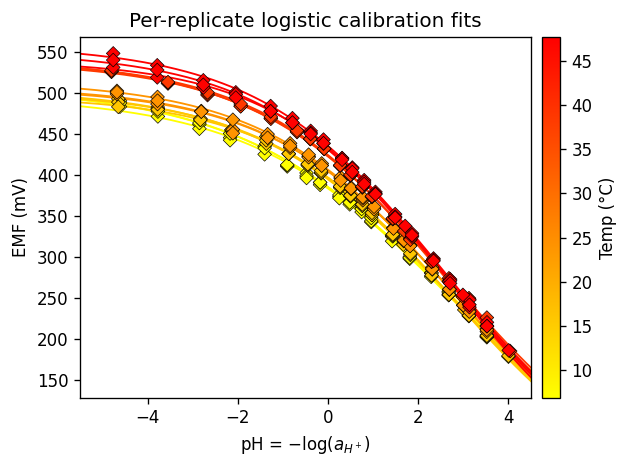

In [7]:
# ---- Calibration data + per-replicate logistic fits ----
fig, ax = plt.subplots(figsize=(5.4, 4.0), dpi=120)
xf = np.linspace(-5.5, 4.5, 400)
for T, popt in run_fits:
    ax.plot(xf, logistic(xf, *popt), "-", color=CMAP(tnorm(T)), lw=1.1, zorder=2)
sc = ax.scatter(pH_all, emf_all, c=T_all, cmap=CMAP, norm=tnorm,
                marker="D", s=34, edgecolors="k", linewidths=0.4, zorder=3)
fig.colorbar(sc, ax=ax, pad=0.02).set_label("Temp (°C)")
ax.set_xlim(-5.5, 4.5)
ax.set_xlabel(XLABEL); ax.set_ylabel("EMF (mV)")
ax.set_title("Per-replicate logistic calibration fits")
plt.tight_layout(); plt.show()


### Step 3. Choose polynomial degree for A(T), k(T), x0(T) by AICc
Each parameter is described by a polynomial in temperature; degrees 1-3 are scored
by the small-sample-corrected Akaike criterion (**AICc**, lowest is best), with
**AICc counting the fitted polynomial coefficients** ($K = \text{degree}+1$). On
this replicate-level dataset AICc selects **A → 3, k → 3, x₀ → 2**. (Averaging the
replicates first, or including the 60 °C outlier, collapses these toward degree 1.)

The plot shows amplitude $A(T)$, growth rate $k(T)$ and midpoint $x_0(T)$ - each
with its AICc-selected polynomial and 95% confidence band. Override any choice with
`DEGREE_A / DEGREE_K / DEGREE_X0`.

In [8]:
def poly_scores(x, y, dmax=3):
    '''AICc, RMSE, adjusted R^2 for polynomial degrees 1..dmax.
    K = number of fitted polynomial coefficients (degree + 1).'''
    x = np.asarray(x, float); y = np.asarray(y, float); n = len(x)
    dmax = min(dmax, n - 2)
    sst = np.sum((y - y.mean())**2)
    rows = []
    for d in range(1, dmax + 1):
        c = np.polyfit(x, y, d)
        rss = float(np.sum((y - np.polyval(c, x))**2))
        K = d + 1
        aic = n * np.log(rss / n) + 2 * K
        den = n - K - 1
        aicc = aic + 2 * K * (K + 1) / den if den > 0 else np.inf
        rmse = np.sqrt(rss / n)
        r2 = 1 - rss / sst
        adjr2 = 1 - (1 - r2) * (n - 1) / (n - d - 1)
        rows.append((d, aicc, rmse, adjr2, c))
    return rows

def choose(name, x, y, override):
    rows = poly_scores(x, y)
    best = min(rows, key=lambda r: r[1])[0]
    print(f"\n{name}(T):  deg      AICc       RMSE     adj R^2")
    for d, aicc, rmse, adjr2, _ in rows:
        mark = "  <- AICc best" if d == best else ""
        print(f"          {d}    {aicc:8.2f}   {rmse:8.4g}   {adjr2:7.3f}{mark}")
    if override is not None:
        best = int(override); print(f"  -> OVERRIDDEN to degree {best}")
    else:
        print(f"  -> AICc selects degree {best}")
    return best, np.polyfit(x, y, best)

# ====== OPTIONAL OVERRIDES (None = pure AICc) ======
DEGREE_A  = None
DEGREE_K  = None
DEGREE_X0 = None
# ===================================================

deg_A,  coef_A  = choose("A",  Tp, parA, DEGREE_A)
deg_k,  coef_k  = choose("k",  Tp, park, DEGREE_K)
deg_x0, coef_x0 = choose("x0", Tp, parx, DEGREE_X0)

A_of_T  = lambda T: np.polyval(coef_A,  T)
k_of_T  = lambda T: np.polyval(coef_k,  T)
x0_of_T = lambda T: np.polyval(coef_x0, T)
print(f"\nSelected degrees ->  A: {deg_A}   k: {deg_k}   x0: {deg_x0}   "
      f"(expected: 3, 3, 2)")



A(T):  deg      AICc       RMSE     adj R^2
          1       65.42      7.492     0.859
          2       61.78      5.969     0.903
          3       58.13      4.653     0.936  <- AICc best
  -> AICc selects degree 3

k(T):  deg      AICc       RMSE     adj R^2
          1     -115.69     0.0179     0.391
          2     -117.79    0.01501     0.536
          3     -125.79    0.01012     0.770  <- AICc best
  -> AICc selects degree 3

x0(T):  deg      AICc       RMSE     adj R^2
          1      -85.42    0.04909     0.235
          2      -94.35    0.03279     0.630  <- AICc best
          3      -90.91    0.03238     0.607
  -> AICc selects degree 2

Selected degrees ->  A: 3   k: 3   x0: 2   (expected: 3, 3, 2)


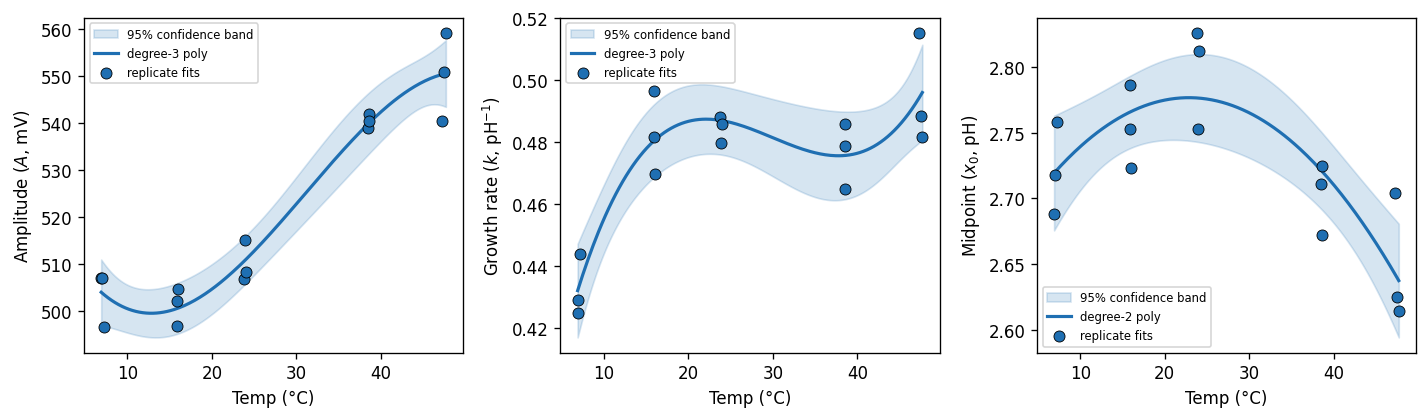

In [9]:
def poly_ci(xg, x, y, deg, coeffs):
    '''95% confidence half-width of a degree-`deg` polynomial fit.'''
    x = np.asarray(x, float); y = np.asarray(y, float); n = len(x); p = deg + 1
    dof = max(n - p, 1)
    s2 = np.sum((y - np.polyval(coeffs, x))**2) / dof
    V = np.vander(x, p); XtXinv = np.linalg.inv(V.T @ V)
    Vg = np.vander(xg, p)
    se = np.sqrt(np.sum((Vg @ XtXinv) * Vg, axis=1) * s2)
    return stats.t.ppf(0.975, dof) * se

BLUE = "#1F6FB2"
Tg = np.linspace(Tp.min(), Tp.max(), 200)
fig, axs = plt.subplots(1, 3, figsize=(12, 3.6), dpi=120)
panels = [("Amplitude ($A$, mV)",            parA, A_of_T,  coef_A,  deg_A),
          ("Growth rate ($k$, pH$^{-1}$)",   park, k_of_T,  coef_k,  deg_k),
          ("Midpoint ($x_0$, pH)",           parx, x0_of_T, coef_x0, deg_x0)]
for ax, (ylab, yv, fn, coef, d) in zip(axs, panels):
    hw = poly_ci(Tg, Tp, yv, d, coef); yg = fn(Tg)
    ax.fill_between(Tg, yg - hw, yg + hw, color=BLUE, alpha=0.18, label="95% confidence band")
    ax.plot(Tg, yg, "-", color=BLUE, lw=1.9, label=f"degree-{d} poly")
    ax.scatter(Tp, yv, s=44, color=BLUE, edgecolors="k", linewidths=0.5, zorder=3, label="replicate fits")
    ax.set_xlabel("Temp (°C)"); ax.set_ylabel(ylab)
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()


### Step 4. Full negative-pH calibration with the temperature-dependent model
Combining $A(T)$, $k(T)$ and $x_0(T)$ gives the complete calibration model
$$\text{EMF}(\text{pH}, T) = \dfrac{A(T)}{1 + \exp\!\big(k(T)\,(\text{pH}-x_0(T))\big)}.$$
The family of curves below (5-50 °C, coloured by temperature) is the negative-pH
calibration used for prediction, plotted over pH -5 to 1.

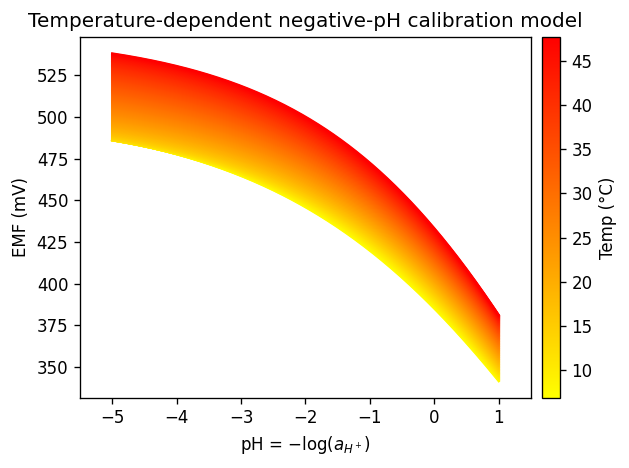

In [10]:
# ---- Full temperature-dependent calibration model EMF(pH, T) ----
pH_grid = np.linspace(-5, 1, 300)           # negative-pH prediction window
T_lo, T_hi = Tp.min(), Tp.max()
mnorm = mpl.colors.Normalize(T_lo, T_hi)

fig, ax = plt.subplots(figsize=(5.4, 4.0), dpi=120)
for T in np.linspace(T_lo, T_hi, 120):
    ax.plot(pH_grid, logistic(pH_grid, A_of_T(T), k_of_T(T), x0_of_T(T)),
            color=CMAP(mnorm(T)), lw=1.3)
sm = mpl.cm.ScalarMappable(cmap=CMAP, norm=mnorm); sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.02).set_label("Temp (°C)")
ax.set_xlim(-5.5, 1.5)
ax.set_xlabel(XLABEL); ax.set_ylabel("EMF (mV)")
ax.set_title("Temperature-dependent negative-pH calibration model")
plt.tight_layout(); plt.show()


### Step 5. Predict sample pH at any temperature
Enter each sample EMF **and** its temperature (5-50 °C).


In [11]:
# ============ EDIT YOUR SAMPLE MEASUREMENTS ============
sample_EMF = [450.0, 500.0]     # measured EMF (mV)
sample_T   = [40.0,  47.0]      # temperature of each sample (deg C)
# ======================================================

sample_EMF = np.atleast_1d(np.asarray(sample_EMF, float))
sample_T   = np.atleast_1d(np.asarray(sample_T, float))
if sample_T.size == 1:
    sample_T = np.full_like(sample_EMF, sample_T[0])

print("EMF (mV) @ T (C)  ->  predicted pH")
for e, T in zip(sample_EMF, sample_T):
    ph = invert_logistic(e, A_of_T(T), k_of_T(T), x0_of_T(T))
    warn = "  (T outside 5-50 C model range)" if (T < Tp.min() or T > Tp.max()) else ""
    flag = "" if np.isfinite(ph) else "  (EMF out of model range)"
    print(f"  {e:8.2f} @ {T:5.1f}  ->  pH {ph:7.3f}{flag}{warn}")


EMF (mV) @ T (C)  ->  predicted pH
    450.00 @  40.0  ->  pH  -0.616
    500.00 @  47.0  ->  pH  -2.022
